In [54]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import nengo
from nengo.dists import Uniform
import scipy.io as sio
from scipy.signal import fftconvolve
import brian2hears as b2h
import brian2 as b2
from brian2 import Hz, kHz
import time
from scipy.signal import butter, sosfilt

Notes for work:
- to think about the global values
- to change the "output" and decoder

In [ ]:
FS = 500_000               
DT_SIM = 0.0001     
STIM_DURATION = 0.3    
DURATION_S = 0.3   
WARMUP_MS = 50      

#Hearing range (Hz)
F_LOW = 2_000 
F_HIGH = 80_000

N_CHANNELS = 20 #tonotopic frequency channels - to think about the value

#Neuron(LIF)
TAU_RC = 0.020 #s, membrane time constant
TAU_REF = 0.005 #s, refractory period
MAX_RATE = 150 #Hz, max firing rate

TAU_EXCIT = 0.00023 #s, excitatory synaptic time constant
TAU_INHIB = 0.00060 #s, inhibitory synaptic time constant

#number of neurons per 1 frequency channel
N_SBC = 30 #neurons per SBC ensemble
N_MNTB = 30 #neurons per MNTB ensemble
N_LSO = 40 #neurons per LSO ensemble

#synaptic weights
W_SBC_LSO = 1.0 #ipsilateral excitatory weight
W_SBC_MNTB = 1.0 #contralateral excitatory weight
W_MNTB_LSO = 1.8 #contralateral inhibitory weight

HRTF_FILE  = '../hrtf/2018-08-15_1000samp_ILDITDmod_correct_noitd_ex_ILD.mat'

ANGLES = list(range(-90, 91, 10))  
SEED = 0
WARMUP_S = 0.05                      
SMOOTH_MS = 10    

In [57]:
data = sio.loadmat('../hrtf/2018-08-15_1000samp_ILDITDmod_correct_noitd_ex_ILD.mat')
hrir = data['allimps_percep']  #(2, 10, 200, 2001)

In [58]:
def angle_to_idx(angle_deg):
    idx = int(angle_deg / 1.8) + 100
    return max(0, min(199, idx))

def make_noise(seed, duration_s = DURATION_S, fs = FS):
    rng = np.random.default_rng(seed)
    n = int(duration_s * fs)
    noise = rng.standard_normal(n)

    sos = butter(4, [1_000/(fs/2), 90_000/(fs / 2)], btype='band', output='sos')
    noise = sosfilt(sos, noise)
    noise /= np.max(np.abs(noise)) + 1e-9
    return noise

def make_spatial_sound(mono, hrir_matrix, angle_deg, elevation_idx = 5):
    idx = angle_to_idx(angle_deg)
    sig_L = fftconvolve(mono, hrir_matrix[1, elevation_idx, idx, :], mode='same')
    sig_R = fftconvolve(mono, hrir_matrix[0, elevation_idx, idx, :], mode='same')
    stereo = np.vstack([sig_L, sig_R]).T.astype(np.float64)
    return b2h.Sound(stereo, samplerate=FS * Hz)

def run_cochlear(sound, n_channels = N_CHANNELS):
    b2.start_scope()

    cf = b2h.erbspace(1*kHz, 90*kHz, n_channels)
    fb_L = b2h.Gammatone(sound.left, cf)
    fb_R = b2h.Gammatone(sound.right, cf)

    rect = lambda x: np.clip(x, 0, np.inf)
    ihc_L = b2h.LowPass(b2h.FunctionFilterbank(fb_L, rect), 1000*Hz)
    ihc_R = b2h.LowPass(b2h.FunctionFilterbank(fb_R, rect), 1000*Hz)

    cL = np.asarray(ihc_L.process()).T #(n_channels, n_audio_samples)
    cR = np.asarray(ihc_R.process()).T

    peak = max(cL.max(), cR.max())+1e-9
    return cL/peak, cR/peak

def _lif():
    return nengo.LIF(tau_rc=TAU_RC, tau_ref=TAU_REF)

def _make_input_fn(envelope, audio_fs = FS):
    T = envelope.shape[1]
    def fn(t):
        idx = min(int(t*audio_fs), T-1)
        return envelope[:,idx]
    return fn

In [ ]:
def _build_and_run(cL, cR):
    I = np.eye(N_CHANNELS)
    w_sum = np.ones((1, N_CHANNELS))
 
    with nengo.Network() as model:
        inp_L = nengo.Node(_make_input_fn(cL), size_out=N_CHANNELS)
        inp_R = nengo.Node(_make_input_fn(cR), size_out=N_CHANNELS)
 
        sbc_L = nengo.Ensemble(N_SBC*N_CHANNELS, N_CHANNELS, neuron_type=_lif(), max_rates=Uniform(40, MAX_RATE))
        sbc_R = nengo.Ensemble(N_SBC*N_CHANNELS, N_CHANNELS, neuron_type=_lif(), max_rates=Uniform(40, MAX_RATE))
        
        mntb_L = nengo.Ensemble(N_MNTB*N_CHANNELS, N_CHANNELS, neuron_type=_lif(), max_rates=Uniform(40, MAX_RATE))
        mntb_R = nengo.Ensemble(N_MNTB*N_CHANNELS, N_CHANNELS, neuron_type=_lif(), max_rates=Uniform(40, MAX_RATE))
        
        lso_L = nengo.Ensemble(N_LSO*N_CHANNELS, N_CHANNELS, neuron_type=_lif(), max_rates=Uniform(20, MAX_RATE))
        lso_R = nengo.Ensemble(N_LSO*N_CHANNELS, N_CHANNELS, neuron_type=_lif(), max_rates=Uniform(20, MAX_RATE))
        
        ild_node = nengo.Node(size_in=1)
 
        nengo.Connection(inp_L,sbc_L,synapse=TAU_EXCIT, transform=I)
        nengo.Connection(inp_R,sbc_R,synapse=TAU_EXCIT, transform=I)
        nengo.Connection(sbc_R,mntb_L,synapse=TAU_EXCIT, transform=I*W_SBC_MNTB)
        nengo.Connection(sbc_L,mntb_R,synapse=TAU_EXCIT, transform=I*W_SBC_MNTB)
        nengo.Connection(sbc_L,lso_L,synapse=TAU_EXCIT, transform=I*W_SBC_LSO)
        nengo.Connection(sbc_R,lso_R,synapse=TAU_EXCIT, transform=I*W_SBC_LSO)
        nengo.Connection(mntb_L,lso_L,synapse=TAU_INHIB, transform=-I*W_MNTB_LSO)
        nengo.Connection(mntb_R,lso_R,synapse=TAU_INHIB, transform=-I*W_MNTB_LSO)
        nengo.Connection(lso_L,ild_node,synapse=TAU_EXCIT, transform=-w_sum)
        nengo.Connection(lso_R,ild_node,synapse=TAU_EXCIT, transform=w_sum)
 
        syn = SMOOTH_MS/1000
        p = {
            'inp_L':nengo.Probe(inp_L,synapse=syn),
            'inp_R':nengo.Probe(inp_R,synapse=syn),
            'sbc_L':nengo.Probe(sbc_L.neurons,synapse=syn),
            'sbc_R':nengo.Probe(sbc_R.neurons,synapse=syn),
            'mntb_L':nengo.Probe(mntb_L.neurons,synapse=syn),
            'mntb_R':nengo.Probe(mntb_R.neurons,synapse=syn),
            'lso_L':nengo.Probe(lso_L.neurons,synapse=syn),
            'lso_R':nengo.Probe(lso_R.neurons,synapse=syn),
            'ild':nengo.Probe(ild_node,synapse=syn),
        }
 
    with nengo.Simulator(model, dt=DT_SIM, progress_bar=False) as sim:
        sim.run(DURATION_S)
 
    warmup = int(WARMUP_S / DT_SIM)
    sl = slice(warmup, None)
 
    def ch_mean(key, n_per_ch):
        d = sim.data[p[key]][sl] #(T, n_ch*n_per_ch)
        T = d.shape[0]
        return d.reshape(T, N_CHANNELS, n_per_ch).mean(axis=2).mean(axis=0)
 
    return {
        'inp_L': sim.data[p['inp_L']][sl].mean(axis=0),
        'inp_R': sim.data[p['inp_R']][sl].mean(axis=0),
        'sbc_L': ch_mean('sbc_L', N_SBC),
        'sbc_R': ch_mean('sbc_R', N_SBC),
        'mntb_L': ch_mean('mntb_L', N_MNTB),
        'mntb_R': ch_mean('mntb_R', N_MNTB),
        'lso_L': ch_mean('lso_L', N_LSO),
        'lso_R': ch_mean('lso_R', N_LSO),
        'ild': float(sim.data[p['ild']][sl].mean()),
        't': sim.trange(),
        'ild_trace': sim.data[p['ild']][:, 0],
    }
 

In [40]:
angles = np.arange(-90, 91, 10)

ild_values = []

for angle in angles:
    print(f"Running {angle:+d}°")

    mono = make_noise(SEED)
    sound = make_spatial_sound(mono, hrir, angle)

    cL, cR = run_cochlear(sound)

    d = _build_and_run(cL, cR)

    ild_values.append(d['ild'])

ild_values = np.array(ild_values)

Running -90°


WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


Running -80°


WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


Running -70°


...

WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


Running +80°


WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


Running +90°


WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: 'utf-8' codec can't decode byte 0x8d in position 122: invalid start byte (UnicodeDecodeError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


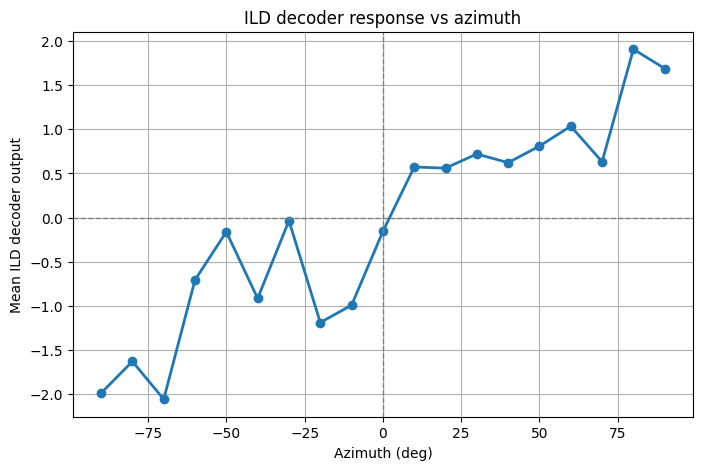

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    angles,
    ild_values,
    marker='o',
    linewidth=2
)

plt.xlabel('Azimuth (deg)')
plt.ylabel('Mean ILD decoder output')
plt.title('ILD decoder response vs azimuth')

plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

plt.show()